# The basic imports

In [1]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

from scipy.linalg import block_diag
# Don't do linear algebra in Python without these two lines
np.set_printoptions(suppress=True)
from collections import Counter
from IPython.display import set_matplotlib_formats
set_matplotlib_formats('retina')

%precision 3
#############################################
import sys
import importlib
importlib.reload(sys)
#######################

/tmp/ipykernel_7247/2336859851.py:13: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('retina')


<module 'sys' (built-in)>

In [2]:
df=pd.read_csv('https://raw.githubusercontent.com/vinayprabhu/APEX_reproduce/refs/heads/main/Fig1c_UMAP.tsv',sep='\t')
# This tsv was was extracted from the first tab of the .xslx file shared here:
# https://static-content.springer.com/esm/art%3A10.1038%2Fs41467-025-60051-6/MediaObjects/41467_2025_60051_MOESM7_ESM.xlsx
print(df.shape) # # The size checks out : 386 VEPs+ 19762 =20148 from DBAASP
df.head(4)

(20148, 6)


,Unnamed: 0,Group,Name,Sequence,UMAP-1,UMAP-2
0,ILPWKWPWWPWRF,Databases,NaN,ILPWKWPWWPWRF,-3.681419,-2.639606
1,GIPCGESCVFIPCLTSAIDCSCKSKVCYRN,Databases,NaN,GIPCGESCVFIPCLTSAIDCSCKSKVCYRN,-1.312189,-5.845187
2,VRLRIRVAVLRA,Databases,NaN,VRLRIRVAVLRA,-0.285407,7.069371
3,WHWTWLRIRKKLR,Databases,NaN,WHWTWLRIRKKLR,0.942622,0.586674


In [3]:
df.columns=['Unnamed', 'Group', 'Name', 'Sequence', 'UMAP_1', 'UMAP_2']
df.head(4)

,Unnamed,Group,Name,Sequence,UMAP_1,UMAP_2
0,ILPWKWPWWPWRF,Databases,NaN,ILPWKWPWWPWRF,-3.681419,-2.639606
1,GIPCGESCVFIPCLTSAIDCSCKSKVCYRN,Databases,NaN,GIPCGESCVFIPCLTSAIDCSCKSKVCYRN,-1.312189,-5.845187
2,VRLRIRVAVLRA,Databases,NaN,VRLRIRVAVLRA,-0.285407,7.069371
3,WHWTWLRIRKKLR,Databases,NaN,WHWTWLRIRKKLR,0.942622,0.586674


There's something off about this file. Especially the first unnamed column

<Axes: >

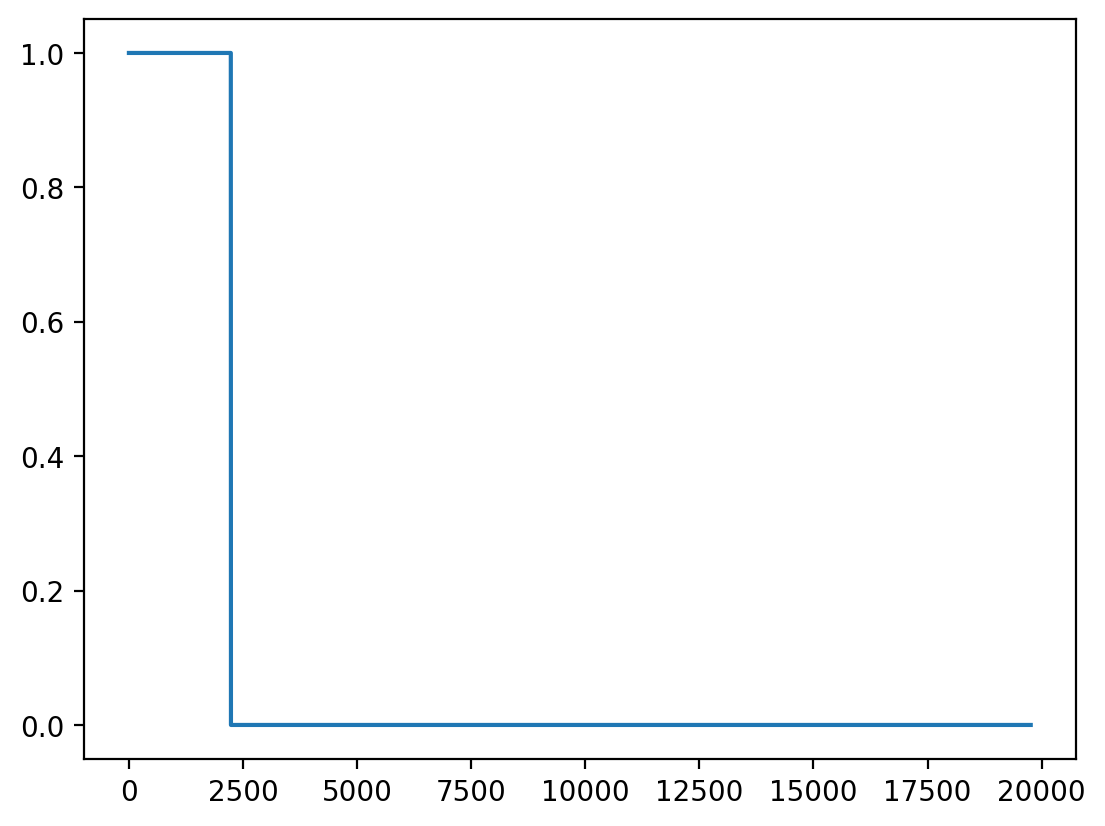

In [4]:
(df.loc[0:19761,'Unnamed']==df.loc[0:19761,'Sequence']).astype(int).plot()

In [5]:
np.where((df.loc[0:19761,'Unnamed']==df.loc[0:19761,'Sequence']).astype(int).values==0)

(array([ 2234,  2235,  2236, ..., 19759, 19760, 19761]),)

So, the first 2233 values are the same

Group
Databases        19762
UniProt            273
Arachnoserver       80
Conoserver          26
ISOB                 7
Name: count, dtype: int64


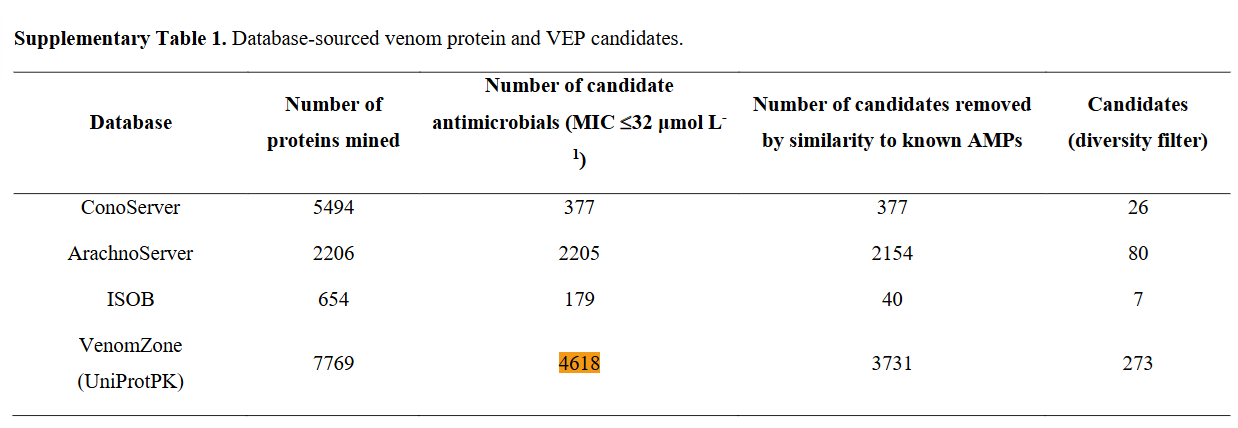

In [6]:
from PIL import Image
import requests
from io import BytesIO
print(df.Group.value_counts())
# Fetch image
response = requests.get('https://raw.githubusercontent.com/vinayprabhu/APEX_reproduce/254973019cb83ea92ad133446350f1ead12d0d84/images/img_4618.png')
img1 = Image.open(BytesIO(response.content))
img1


Now, let's check if the fig1c UMAP scatterplot can be replicated

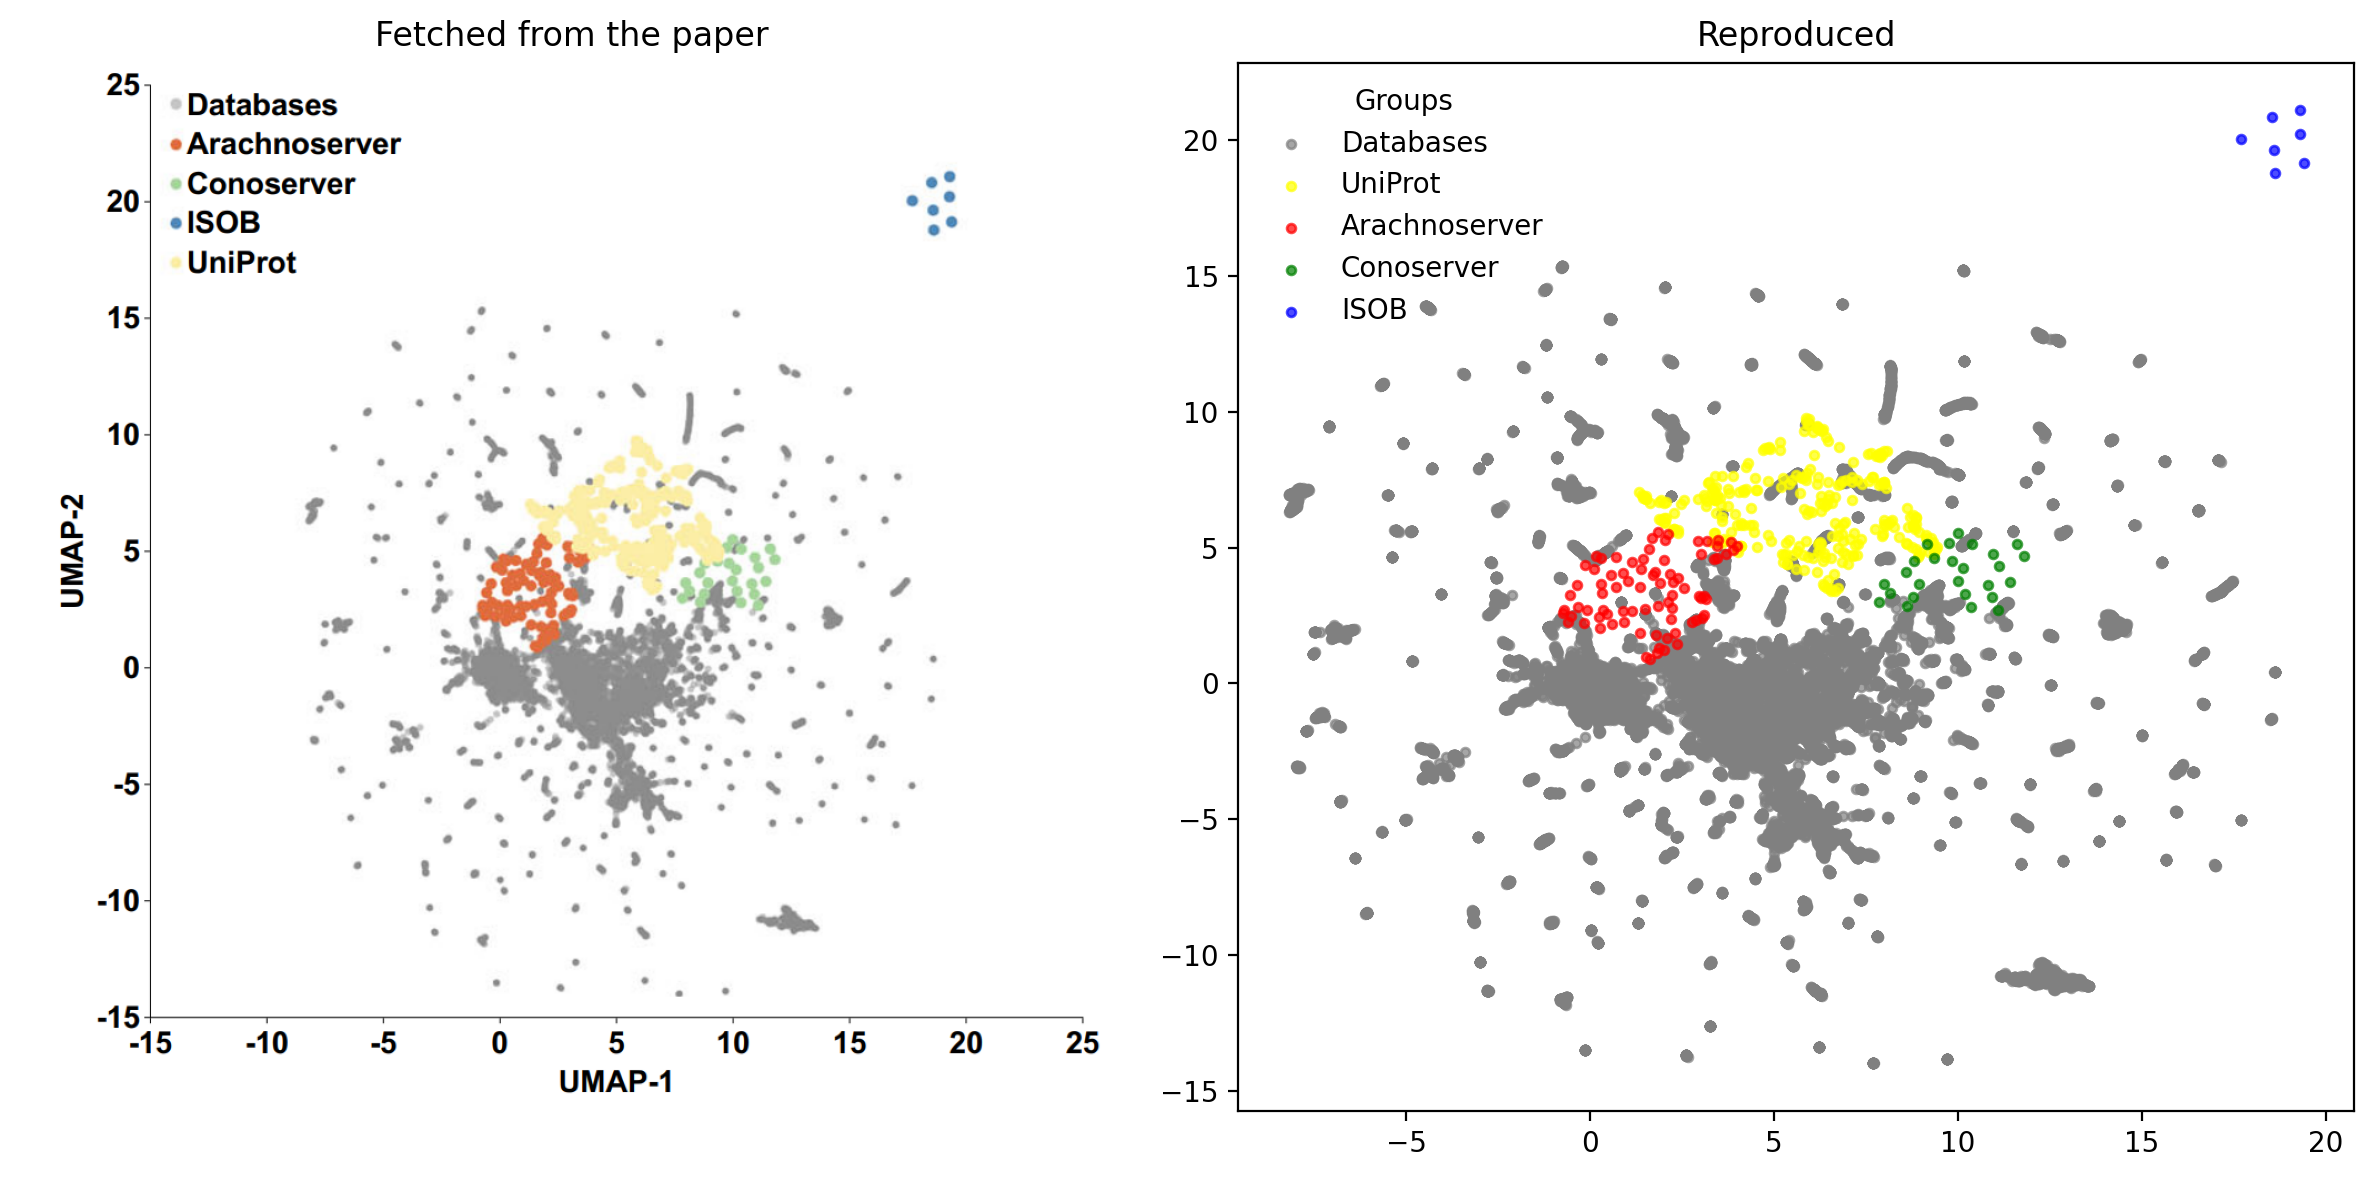

In [7]:
import matplotlib.pyplot as plt

category_palette = {
    'Databases': 'grey',
    'UniProt': 'yellow',
    'Arachnoserver': 'red',
    'Conoserver': 'green',
    'ISOB': 'blue'
}

# Map the group column to the color list
colors = df['Group'].map(category_palette)




# URL defined in previous context
url1 = 'https://raw.githubusercontent.com/vinayprabhu/APEX_reproduce/7a8ad07cc2f132f4ef8004e5ddc7ec8ac08cb43e/images/fig_1c.png'

# Fetch image
response = requests.get(url1)
img1 = Image.open(BytesIO(response.content))

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot Image
axes[0].imshow(img1)
axes[0].axis('off')
axes[0].set_title("Fetched from the paper")

# Plot Scatter
# 1. Define the palette mapping
category_palette = {
    'Databases': 'grey',
    'UniProt': 'yellow',
    'Arachnoserver': 'red',
    'Conoserver': 'green',
    'ISOB': 'blue'
}

# 2. Iterate and plot by group to enable the legend
for group, color in category_palette.items():
    subset = df[df['Group'] == group]
    axes[1].scatter(
        subset['UMAP_1'],
        subset['UMAP_2'],
        c=color,
        label=group,
        alpha=0.7,
        s=10
    )

# 3. Add the legend to the scatter plot
# 3. Add the legend without the box in the top left
axes[1].legend(
    title="Groups",
    loc='upper left',
    frameon=False
)
axes[1].set_title("Reproduced")


plt.tight_layout()
plt.savefig('combined_plot.png')
plt.show()

In [8]:
df_dbaasp=df.loc[:,[ 'Sequence','Group','Unnamed']]
df_dbaasp.columns=['sequence','dataset','sequence_2']
# Replace 'Databases' with 'DBAASP' in the dataset column
df_dbaasp['dataset'] = df_dbaasp['dataset'].replace('Databases', 'DBAASP')
df_dbaasp
# df_dbaasp.to_csv('./data/df_dbaasp_veps_20148x3.tsv',sep='\t',index=False)

,sequence,dataset,sequence_2
0,ILPWKWPWWPWRF,DBAASP,ILPWKWPWWPWRF
1,GIPCGESCVFIPCLTSAIDCSCKSKVCYRN,DBAASP,GIPCGESCVFIPCLTSAIDCSCKSKVCYRN
2,VRLRIRVAVLRA,DBAASP,VRLRIRVAVLRA
3,WHWTWLRIRKKLR,DBAASP,WHWTWLRIRKKLR
4,PDPAKTAPKKGSKKAVTKA,DBAASP,PDPAKTAPKKGSKKAVTKA
...,...,...,...
20143,RGLFGKLIKKFGRKAISYAVK,UniProt,NaN
20144,IKWGKIFKKGGKLI,UniProt,NaN
20145,AMRRYQHRMRVKQMYRRIKMKQMYRHMKWMGMYRQAKAARLR,UniProt,NaN
20146,GKLKKVLHFIQKSVSKI,UniProt,NaN
